# Importing libraries

In [116]:
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import os
import fiona
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import numpy as np
import pandas as pd
from scipy.stats import linregress

# Loading data sets

In [117]:
#Load prescreened MSR shapes (with LCOE and CAPEX values defined) 
S3_MSR_pv_file = str(os.path.dirname(os.getcwd())) + r'\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia_TandR_costs\SolarPV_prescreen.shp'
S3_MSR_wind_file = str(os.path.dirname(os.getcwd())) + r'\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia_TandR_costs\Wind_prescreen.shp'

In [118]:
gdf3wind = gpd.read_file(S3_MSR_wind_file)
gdf3solar = gpd.read_file(S3_MSR_pv_file)

In [119]:
def generate_supply_curve(geo_dataframe,ranking_col,accumulation_col,ascending=True,):
    """
    Creates a supply curve by sorting a dataframe (geo_dataframe) based on [ranking_col] and 
    accumulating values based on [accumulation_col], using matplotlib.
    """

    # Copy to avoid altering original
    df = geo_dataframe[[ranking_col, accumulation_col]].copy()

    # Sort by chosen metric
    df = df.sort_values(ranking_col, ascending=ascending).reset_index(drop=True)

    # Create cumulative sum
    df["cumulative"] = df[accumulation_col].cumsum()

    # Matplotlib figure
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(df["cumulative"], df[ranking_col], marker='o', linestyle='-')
    
    ax.set_title(f"Supply Curve: {ranking_col} vs cumulative {accumulation_col}")
    ax.set_xlabel(f"Cumulative {accumulation_col}")
    ax.set_ylabel(f"{ranking_col}")

    ax.grid(True)
    
    plt.show()
    
    return df

# Check of potential fitting curve types

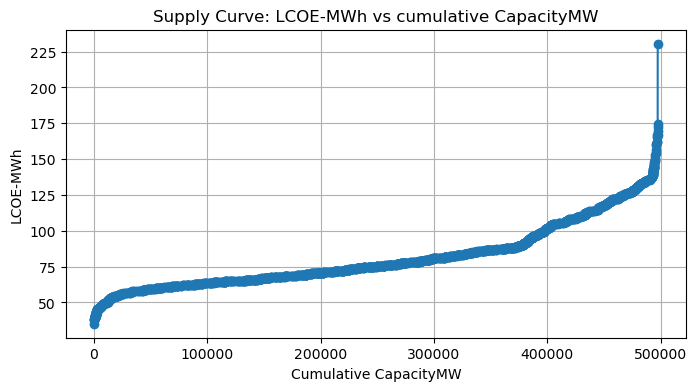

In [120]:
df = generate_supply_curve(geo_dataframe=gdf3wind,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",ascending=True)

In [121]:
capacity = df["cumulative"].values      # accumulated capacity
lcoe = df["LCOE-MWh"].values            # USD/MWh

In [122]:
print(df.describe())
print(df.isna().sum())

          LCOE-MWh   CapacityMW     cumulative
count  1412.000000  1412.000000    1412.000000
mean     85.911027   352.301319  276657.378774
std      26.232140   520.767400  153276.856890
min      35.117358    20.189537      22.049100
25%      66.757027    33.937018  149776.285051
50%      80.009533    82.059842  297235.137424
75%     103.304345   463.341019  402978.674047
max     230.482694  2665.018885  497449.462176
LCOE-MWh      0
CapacityMW    0
cumulative    0
dtype: int64


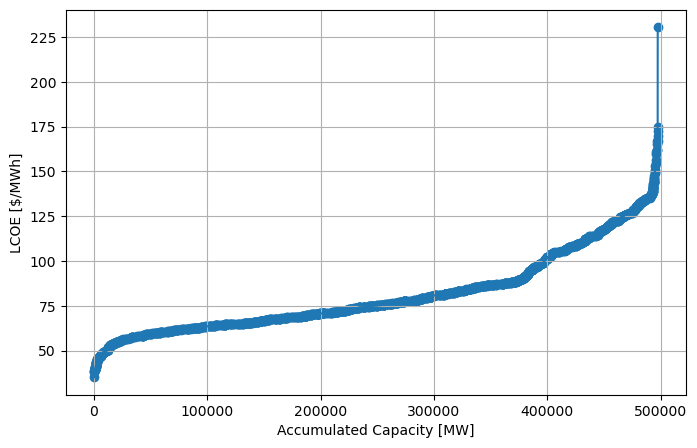

In [123]:
# Check Cost Supply Curve
plt.figure(figsize=(8,5))
plt.scatter(capacity, lcoe)
plt.plot(capacity, lcoe)
plt.xlabel("Accumulated Capacity [MW]")
plt.ylabel("LCOE [$/MWh]")
plt.grid()
plt.show()

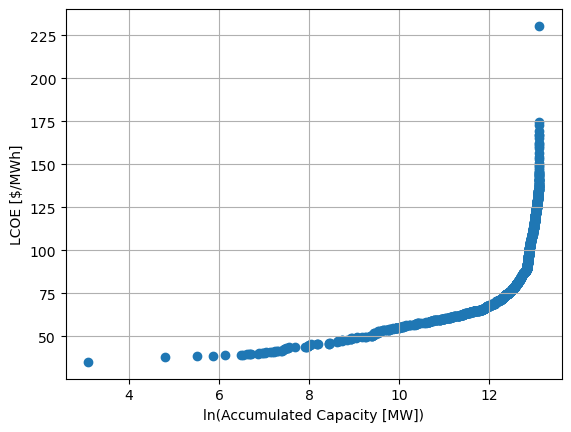

In [124]:
# Check logaritmic relation with: LCOE=a+bln(Capacity) 
plt.scatter(np.log(capacity), lcoe)
plt.xlabel("ln(Accumulated Capacity [MW])")
plt.ylabel("LCOE [$/MWh]")
plt.grid()
plt.show()

No discernable trend

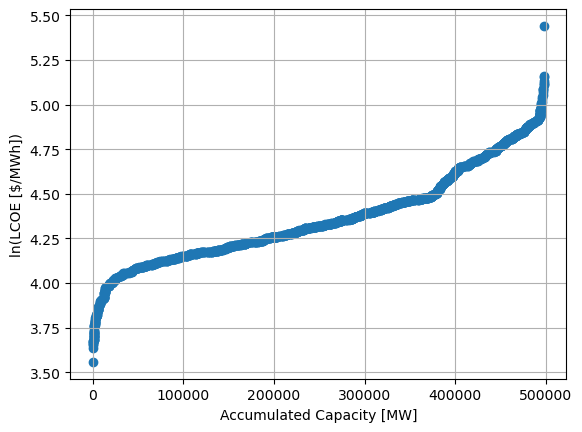

In [125]:
# Check logaritmic relation with: lon(LCOE)=a+b(Capacity) 
plt.scatter(capacity, np.log(lcoe))
plt.xlabel("Accumulated Capacity [MW]")
plt.ylabel("ln(LCOE [$/MWh])")
plt.grid()
plt.show()

No discernable trend

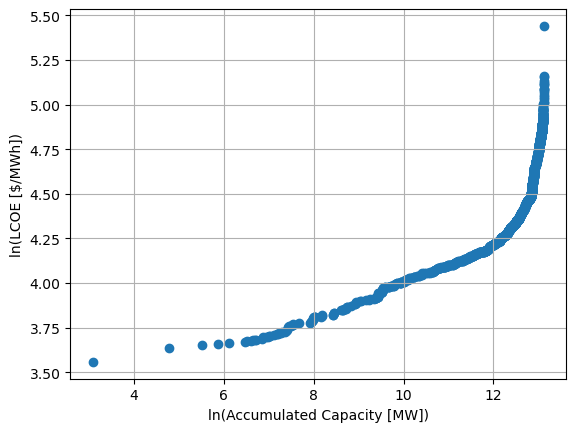

In [126]:
# Check power law relation with: LCOE=a*e^(b*Capacity)
plt.scatter(np.log(capacity), np.log(lcoe))
plt.xlabel("ln(Accumulated Capacity [MW])")
plt.ylabel("ln(LCOE [$/MWh])")
plt.grid()
plt.show()

No discernable trend

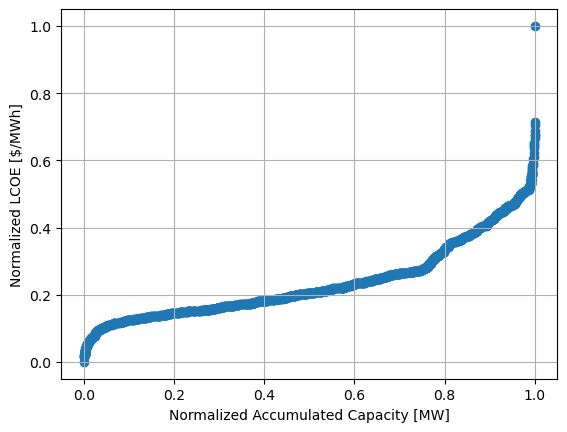

In [127]:
# Check normalized linear relation 
q_norm = capacity / capacity.max()
c_norm = (lcoe - lcoe.min()) / (lcoe.max() - lcoe.min())
plt.scatter(q_norm, c_norm)
plt.xlabel("Normalized Accumulated Capacity [MW]")
plt.ylabel("Normalized LCOE [$/MWh]")
plt.grid()
plt.show()

No discernable trend

C:\Users\Carlos\AppData\Local\Temp\ipykernel_50752\3051886779.py:4: RuntimeWarning: divide by zero encountered in log
  plt.scatter(np.log(remaining), lcoe)


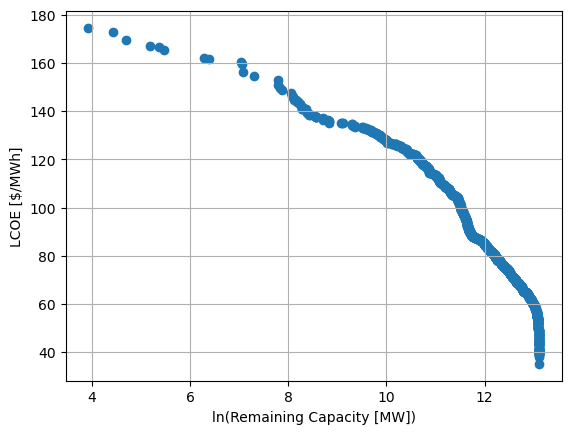

In [128]:
# Check logarithmic relation with remaining capacity: LCOE=a+bln(Remaining Capacity)
capacity_max = max(capacity)
remaining = capacity_max - capacity
plt.scatter(np.log(remaining), lcoe)
plt.xlabel("ln(Remaining Capacity [MW])")
plt.ylabel("LCOE [$/MWh]")
plt.grid()
plt.show()

No discernable trend

# Check a piecewise distribution for the curve

## testing with entire data set curve

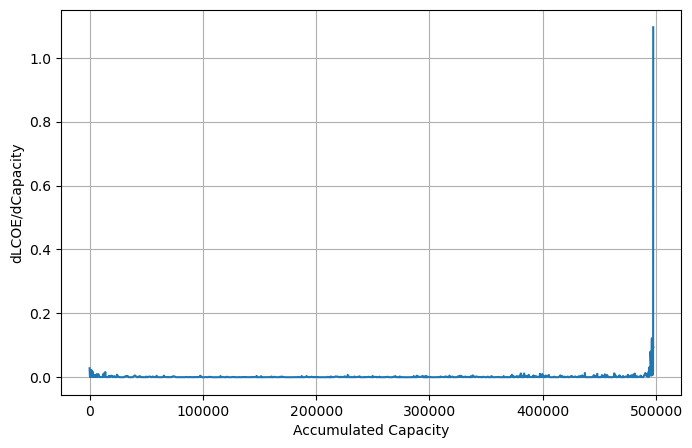

In [129]:
#Check derivative of LCOE with respect to capacity to identify inflection points in the supply curve
slope = np.gradient(lcoe, capacity)

plt.figure(figsize=(8,5))
plt.plot(capacity, slope)
plt.xlabel("Accumulated Capacity")
plt.ylabel("dLCOE/dCapacity")
plt.grid()
#plt.show()

No clear inflexion points for the curve (aside of the last one)

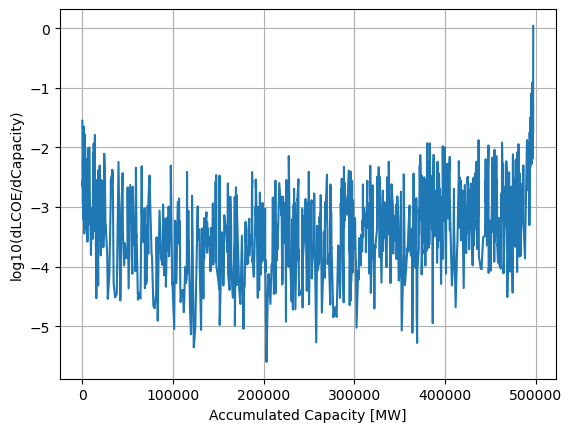

In [130]:
#Check logarithmic relation of the slope with capacity
plt.plot(
    capacity,
    np.log10(slope)
)
plt.xlabel("Accumulated Capacity [MW]")
plt.ylabel("log10(dLCOE/dCapacity)")
plt.grid()
plt.show()

No clear inflexion points for the curve (aside of the last one)

## testing with trimmed data set (removing outlier tail)

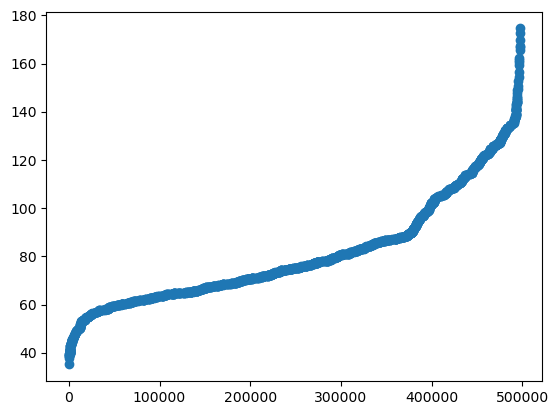

In [131]:
#Trimming the last point to avoid issues with the derivative at the end of the curve
capacity2 = capacity[:-1]
lcoe2 = lcoe[:-1]

slope2 = np.gradient(
    lcoe2,
    capacity2
)

plt.scatter(   
    capacity2,
    lcoe2
)
plt.show()

extreme value for the most expensive region has been trimmed

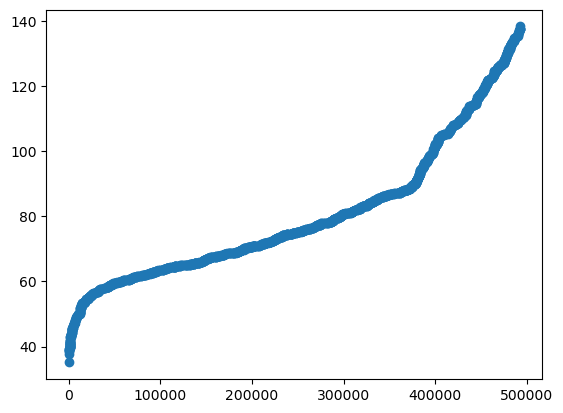

In [132]:
# secondary option to trim the last point is to set it to NaN (using % instead of just removing 1 point)
q_cut = 0.99 * capacity.max()

mask = capacity <= q_cut

capacity_fit = capacity[mask]
lcoe_fit = lcoe[mask]

plt.scatter(
    capacity_fit,
    lcoe_fit
)
plt.show()

last bin with high increase has also been trimmed with the percentage approach

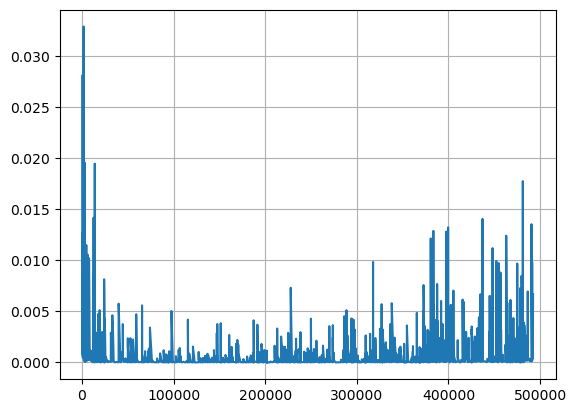

In [133]:
dQ = np.diff(capacity_fit)
dLCOE = np.diff(lcoe_fit)

ratio = dLCOE / dQ

plt.plot(capacity_fit[1:], ratio)
#plt.yscale('log')  # likely useful
plt.grid()

change ratio (delta lcoe/delta capacity) seems to change at around 30k (it stabilizes) and also after 350k 

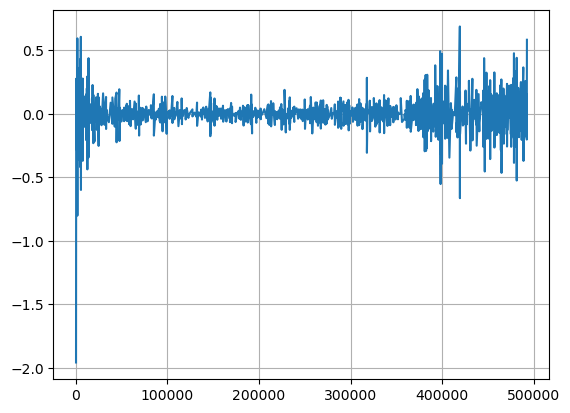

In [134]:
curvature = np.diff(
    np.diff(lcoe_fit)
)

plt.plot(capacity_fit[2:], curvature)
plt.grid()

curvature ratio (second difference of lcoe) follows a reduction trend until  to change at around 30 and 40k (it stabilizes) and big changes start to appear again after 350k 

## testing piecewise funtions (log, linear and cuadratic)

In [135]:
import numpy as np
from scipy.optimize import curve_fit

def three_piece_model(x, knot1, knot2, a, c1, m, d, e):
    # Outputs array
    y = np.zeros_like(x, dtype=float)
    
    # --- REGION 1: The Beginning (Logarithmic) ---
    mask1 = x < knot1
    y[mask1] = a * np.log(x[mask1] + 1) + c1
    
    # Calculate exact connection point at knot1
    y1_at_knot1 = a * np.log(knot1 + 1) + c1
    
    # --- REGION 2: The Middle (Linear) ---
    mask2 = (x >= knot1) & (x < knot2)
    y[mask2] = m * (x[mask2] - knot1) + y1_at_knot1
    
    # Calculate exact connection point at knot2
    y2_at_knot2 = m * (knot2 - knot1) + y1_at_knot1
    
    # --- REGION 3: The End (Quadratic) ---
    mask3 = x >= knot2
    dx3 = x[mask3] - knot2
    y[mask3] = d * (dx3**2) + e * dx3 + y2_at_knot2
    
    return y



In [136]:
# Initial guesses for: [knot1, knot2, a, c1, m, d, e]
# We give the algorithm a reasonable starting ballpark for the knots
initial_guesses = [30000, 370000, 5.0, 35.0, 0.0001, 0.00000001, 0.0001]

# Set bounds to keep knots within logical limits
# e.g., knot1 must be between 10k-100k; knot2 must be between 300k-450k
lower_bounds = [10000, 300000, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf]
upper_bounds = [100000, 450000, np.inf, np.inf, np.inf, np.inf, np.inf]

popt, _ = curve_fit(
    three_piece_model, 
    capacity_fit, 
    lcoe_fit, 
    p0=initial_guesses, 
    bounds=(lower_bounds, upper_bounds)
)

# Unpack the optimized parameters in order
knot1, knot2, a, c1, m, d, e = popt

print("--- OPTIMIZED COEFFICIENTS ---")
print(f"Knot 1 (First split):  {knot1:,.2f}")
print(f"Knot 2 (Second split): {knot2:,.2f}")
print(f"a  (Log multiplier):   {a:.6f}")
print(f"c1 (Log Y-intercept):  {c1:.6f}")
print(f"m  (Linear slope):      {m:.8f}")
print(f"d  (Quadratic curve):   {d:.12f}")
print(f"e  (Quadratic linear):  {e:.8f}")
print("------------------------------")

--- OPTIMIZED COEFFICIENTS ---
Knot 1 (First split):  47,472.18
Knot 2 (Second split): 361,664.26
a  (Log multiplier):   4.425267
c1 (Log Y-intercept):  10.302831
m  (Linear slope):      0.00008894
d  (Quadratic curve):   0.000000000202
e  (Quadratic linear):  0.00035274
------------------------------


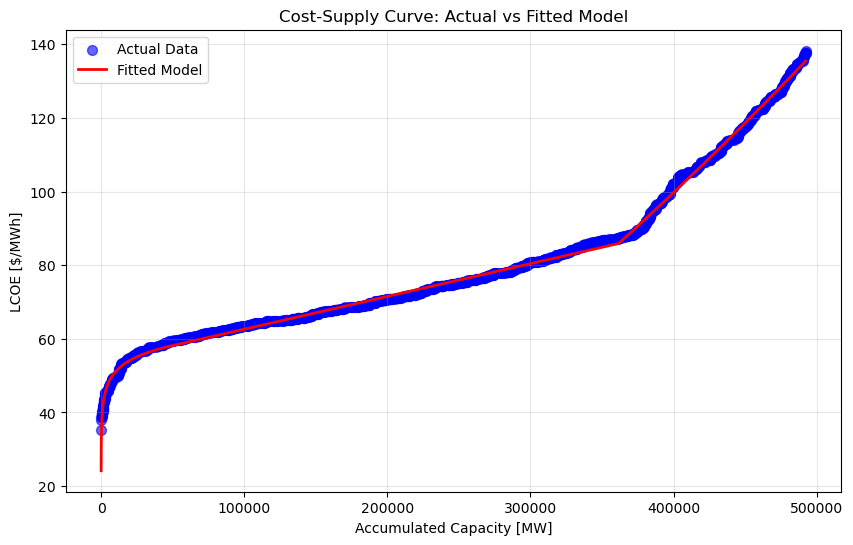

In [137]:
# Generate predicted LCOE values using the optimized parameters
lcoe_predicted = three_piece_model(capacity_fit, knot1, knot2, a, c1, m, d, e)

# Create the overlay plot
plt.figure(figsize=(10, 6))

# Plot actual data points
plt.scatter(capacity_fit, lcoe_fit, color='blue', label='Actual Data', alpha=0.6, s=50)

# Plot the fitted curve
plt.plot(capacity_fit, lcoe_predicted, color='red', linewidth=2, label='Fitted Model')

plt.xlabel("Accumulated Capacity [MW]")
plt.ylabel("LCOE [$/MWh]")
plt.title("Cost-Supply Curve: Actual vs Fitted Model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

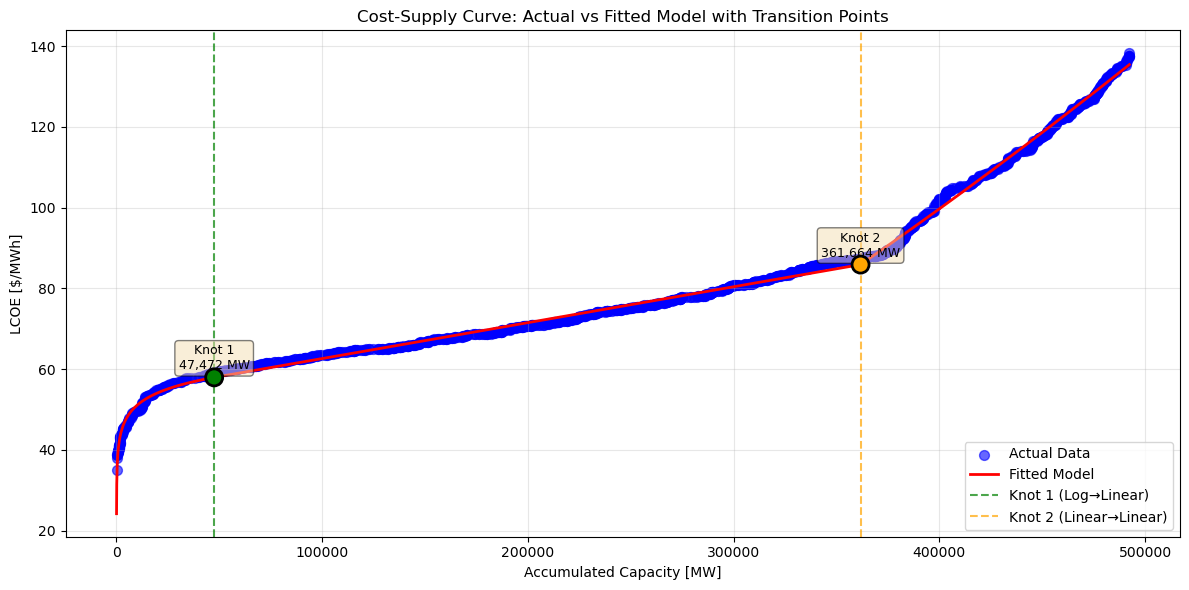

In [138]:
# Generate predicted LCOE values using the optimized parameters
lcoe_predicted = three_piece_model(capacity_fit, knot1, knot2, a, c1, m, d, e)

# Calculate LCOE values at the knots (single scalar values)
lcoe_at_knot1 = three_piece_model(np.array([knot1]), knot1, knot2, a, c1, m, d, e)[0]
lcoe_at_knot2 = three_piece_model(np.array([knot2]), knot1, knot2, a, c1, m, d, e)[0]

# Create the overlay plot
plt.figure(figsize=(12, 6))

# Plot actual data points
plt.scatter(capacity_fit, lcoe_fit, color='blue', label='Actual Data', alpha=0.6, s=50)

# Plot the fitted curve
plt.plot(capacity_fit, lcoe_predicted, color='red', linewidth=2, label='Fitted Model')

# Highlight the knots
plt.axvline(x=knot1, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Knot 1 (Log→Linear)')
plt.axvline(x=knot2, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Knot 2 (Linear→Linear)')

# Mark the knot points on the curve
plt.scatter([knot1, knot2], [lcoe_at_knot1, lcoe_at_knot2], 
            color=['green', 'orange'], s=150, marker='o', edgecolors='black', linewidth=2, zorder=5)

# Add text annotations for the knots
plt.text(knot1, lcoe_at_knot1 + 2, f'Knot 1\n{knot1:,.0f} MW', 
         ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(knot2, lcoe_at_knot2 + 2, f'Knot 2\n{knot2:,.0f} MW', 
         ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.xlabel("Accumulated Capacity [MW]")
plt.ylabel("LCOE [$/MWh]")
plt.title("Cost-Supply Curve: Actual vs Fitted Model with Transition Points")
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## testing piecewise funtions for all linear fits

In [139]:
import numpy as np
from scipy.optimize import curve_fit

def all_linear_piecewise(x, knot1, knot2, m1, c1, m2, m3):
    y = np.zeros_like(x, dtype=float)
    
    # --- REGION 1: The Beginning (Linear) ---
    mask1 = x < knot1
    y[mask1] = m1 * x[mask1] + c1
    
    # Calculate connection height at knot1
    y1_at_knot1 = m1 * knot1 + c1
    
    # --- REGION 2: The Middle (Linear) ---
    mask2 = (x >= knot1) & (x < knot2)
    y[mask2] = m2 * (x[mask2] - knot1) + y1_at_knot1
    
    # Calculate connection height at knot2
    y2_at_knot2 = m2 * (knot2 - knot1) + y1_at_knot1
    
    # --- REGION 3: The End (Linear) ---
    mask3 = x >= knot2
    y[mask3] = m3 * (x[mask3] - knot2) + y2_at_knot2
    
    return y

# Initial guesses for: [knot1, knot2, m1, c1, m2, m3]
# Note: Because the beginning is steep, m1 needs a larger initial guess than m2.
initial_guesses = [30000, 370000, 0.0007, 35.0, 0.00009, 0.0003]

# Set bounds for the knots just like before
lower_bounds = [10000, 300000, -np.inf, -np.inf, -np.inf, -np.inf]
upper_bounds = [100000, 450000, np.inf, np.inf, np.inf, np.inf]

popt, _ = curve_fit(
    all_linear_piecewise, 
    capacity_fit, 
    lcoe_fit,  
    p0=initial_guesses, 
    bounds=(lower_bounds, upper_bounds)
)

In [140]:
# Unpack the optimized linear parameters
knot1, knot2, m1, c1, m2, m3 = popt

print("--- OPTIMIZED LINEAR COEFFICIENTS ---")
print(f"Knot 1 (First split):  {knot1:,.2f}")
print(f"Knot 2 (Second split): {knot2:,.2f}")
print(f"m1 (Beginning slope):  {m1:.8f}")
print(f"c1 (Initial Y-intercept): {c1:.6f}")
print(f"m2 (Middle slope):     {m2:.8f}")
print(f"m3 (End slope):        {m3:.8f}")
print("-------------------------------------")

--- OPTIMIZED LINEAR COEFFICIENTS ---
Knot 1 (First split):  16,447.10
Knot 2 (Second split): 364,033.70
m1 (Beginning slope):  0.00088547
c1 (Initial Y-intercept): 40.610047
m2 (Middle slope):     0.00008916
m3 (End slope):        0.00038014
-------------------------------------


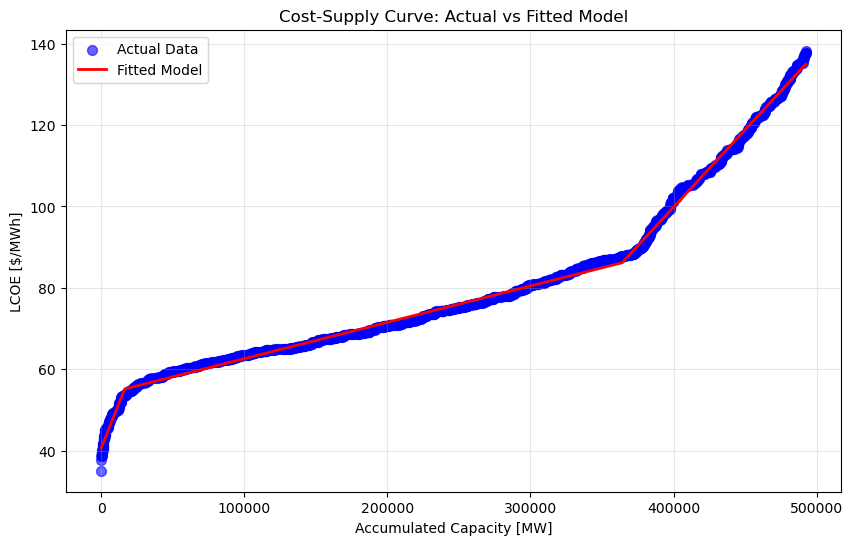

In [141]:
# Generate predicted LCOE values using the optimized parameters
lcoe_predicted = all_linear_piecewise(capacity_fit, knot1, knot2, m1, c1, m2, m3)

# Create the overlay plot
plt.figure(figsize=(10, 6))

# Plot actual data points
plt.scatter(capacity_fit, lcoe_fit, color='blue', label='Actual Data', alpha=0.6, s=50)

# Plot the fitted curve
plt.plot(capacity_fit, lcoe_predicted, color='red', linewidth=2, label='Fitted Model')

plt.xlabel("Accumulated Capacity [MW]")
plt.ylabel("LCOE [$/MWh]")
plt.title("Cost-Supply Curve: Actual vs Fitted Model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

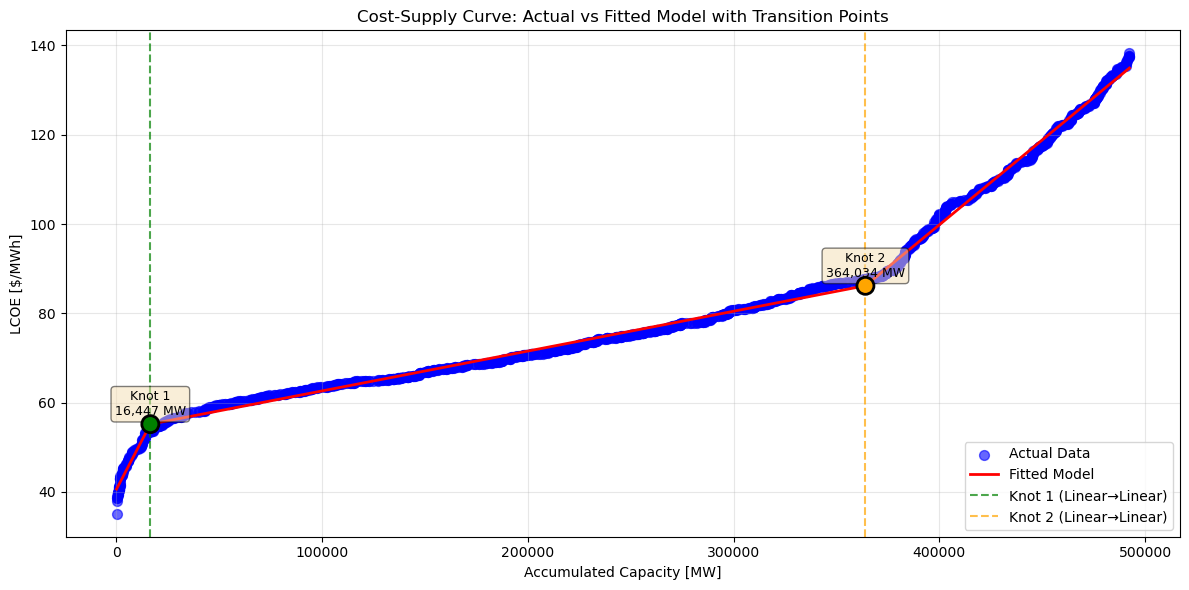

In [142]:
# Generate predicted LCOE values using the optimized parameters
lcoe_predicted = all_linear_piecewise(capacity_fit, knot1, knot2, m1, c1, m2, m3)

# Calculate LCOE values at the knots
lcoe_at_knot1 = all_linear_piecewise(np.array([knot1]), knot1, knot2, m1, c1, m2, m3)[0]
lcoe_at_knot2 = all_linear_piecewise(np.array([knot2]), knot1, knot2, m1, c1, m2, m3)[0]

# Create the overlay plot
plt.figure(figsize=(12, 6))

# Plot actual data points
plt.scatter(capacity_fit, lcoe_fit, color='blue', label='Actual Data', alpha=0.6, s=50)

# Plot the fitted curve
plt.plot(capacity_fit, lcoe_predicted, color='red', linewidth=2, label='Fitted Model')

# Highlight the knots
plt.axvline(x=knot1, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Knot 1 (Linear→Linear)')
plt.axvline(x=knot2, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Knot 2 (Linear→Linear)')

# Mark the knot points on the curve
plt.scatter([knot1, knot2], [lcoe_at_knot1, lcoe_at_knot2], 
            color=['green', 'orange'], s=150, marker='o', edgecolors='black', linewidth=2, zorder=5)

# Add text annotations for the knots
plt.text(knot1, lcoe_at_knot1 + 2, f'Knot 1\n{knot1:,.0f} MW', 
         ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(knot2, lcoe_at_knot2 + 2, f'Knot 2\n{knot2:,.0f} MW', 
         ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.xlabel("Accumulated Capacity [MW]")
plt.ylabel("LCOE [$/MWh]")
plt.title("Cost-Supply Curve: Actual vs Fitted Model with Transition Points")
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()